In [2]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# **The `OptionPricer` Class**
The `OptionPricer` class serves as the central computational engine for this project. It encapsulates the pricing logic for equity derivatives, providing a unified interface for comparing discrete and continuous pricing models.

Key Functionalities:

    1. Binomial Tree Model: Implements a vectorized Cox-Ross-Rubinstein (CRR) approach to price both European and American options, explicitly handling the early exercise boundary.
    2. Black-Scholes Model: Provides the analytical closed-form solution for European options to serve as a convergence benchmark.
    3. Implied Volatility Solver: Utilizes numerical root-finding algorithms to back-solve volatility from observed market prices.

Class Attributes: The class is initialized with the standard financial parameters required for option valuation:

    s0 : float
        Initial stock price.
    K : float
        Strike price.
    r : float
        Risk-free interest rate (annualized).
    sigma : float
        Volatility of the underlying asset.
    T : float
        Time to maturity (in years).
    N : int
        Number of time steps in the binomial tree.

In [3]:
class OptionPricer:
    def __init__(self, s0, K, r, sigma, T, N):
        self.s0 = s0
        self.K = K
        self.r = r
        self.sigma = sigma
        self.T = T
        self.N = N
        self.dt = T / N
        self.df = np.exp(-r * self.dt)

    def _setup_params(self):
        u = np.exp(self.sigma * np.sqrt(self.dt))
        d = 1 / u
        qu = (np.exp(self.r * self.dt) - d) / (u - d)
        qd = 1 - qu
        return u, d, qu, qd

    def _payoff(self, prices, option_type):
        if option_type == "call":
            return np.maximum(prices - self.K, 0)
        elif option_type == "put":
            return np.maximum(self.K - prices, 0)


    def binomial_price(self, option_style="european", option_type="call"):
        u, d, qu, qd = self._setup_params()

        final_prices = self.s0 * (u ** np.arange(self.N, -1, -1)) * (d ** np.arange(0, self.N + 1, 1))

        values = self._payoff(final_prices, option_type)
        current_stock_prices = final_prices

        for i in range(self.N):
            hold_values = self.df * (qu * values[:-1] + qd * values[1:])

            if option_style == "american":
                current_stock_prices = current_stock_prices[:-1] / u
                intrinsic_values = self._payoff(current_stock_prices, option_type)
                values = np.maximum(hold_values, intrinsic_values)
            else:
                values = hold_values

        return values[0]

    def black_scholes(self, option_type="call", sigma = None):
            vol = sigma if sigma is not None else self.sigma

            d1 = (np.log(self.s0 / self.K) + (self.r + 0.5 * vol ** 2) * self.T) / (vol * np.sqrt(self.T))
            d2 = d1 - vol * np.sqrt(self.T)

            if option_type == "call":
                return self.s0 * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)
            elif option_type == "put":
                return self.K * np.exp(-self.r * self.T) * norm.cdf(-d2) - self.s0 * norm.cdf(-d1)

    def calculate_implied_volatility(self, market_price, option_type="call"):

        def objective_function(sigma_guess):
            bs_price = self.black_scholes(option_type, sigma=sigma_guess[0])
            error = (bs_price - market_price) ** 2
            return error

        initial_guess = [0.3]
        bounds = [(0.001, 5.0)]

        result = minimize(objective_function, initial_guess, bounds=bounds, method='SLSQP')
        return result.x[0]

# **Validation with Real-Market Data: Amazon (AMZN)**
To assess the practical accuracy of the Binomial model, we calibrate the algorithm against real-world option premiums for Amazon.com Inc. (AMZN). The market data was captured on January 24.

Market Parameters:

    Spot Price (s0): $239.16
    Risk-Free Rate (r): 3.786% (Annualized)
    Time to Maturity (T): 5 months (≈ 0.41 years)
    Discretization (N): 50 steps

Target Options for Calibration: We select two distinct contracts to test the model's performance on both sides of the market (Call vs. Put) and different moneyness levels:

Call Option:

        K = 245
        sigma = 0.3818
        bid_ask_price = 24.95

Put Option:

        K = 210
        sigma = 0.34
        bid_ask_price = 11.2

In [20]:
CALL_DATA = {
        "s0": 239.16,
        "K":245,
        "r": 0.03768,
        "sigma": 0.3818,
        "T": 5/12,
        "N": 50
        }
PUT_DATA = {
        "s0": 239.16,
        "K":210,
        "r": 0.03768,
        "sigma": 0.3818,
        "T": 5/12,
        "N": 50
}
call_price = 24.95
put_price = 11.20

In [19]:
# Call Option Test [AMZ]
model_call = OptionPricer(**CALL_DATA)

euro_price = model_call.binomial_price(option_style="european", option_type="call")
american_price = model_call.binomial_price(option_style="american", option_type="call")
black_scholes_price = model_call.black_scholes(option_type="call")

print("==== Call Option ===")
print(f"European Call Option Price: {euro_price:.2f} (Expected: {call_price:.2f})")
print(f"American Call Option Price: {american_price:.2f} (Expected: {call_price:.2f})")
print(f"Black-Scholes Call Option Price: {black_scholes_price:.2f} (Expected: {call_price:.2f})")


# Put Option Test [AMZ]
model_put = OptionPricer(**PUT_DATA)

euro_price = model_put.binomial_price(option_style="european", option_type="put")
american_price = model_put.binomial_price(option_style="american", option_type="put")
black_scholes_price = model_put.black_scholes(option_type="put")

print("\n==== Put Option ===")
print(f"European Put Option Price: {euro_price:.2f} (Expected: {put_price:.2f})")
print(f"American Put Option Price: {american_price:.2f} (Expected: > {put_price:.2f})")
print(f"Black-Scholes Put Option Price: {black_scholes_price:.2f} (Expected: {put_price:.2f})")


==== Call Option ===
European Call Option Price: 22.65 (Expected: 24.95)
American Call Option Price: 22.65 (Expected: 24.95)
Black-Scholes Call Option Price: 22.56 (Expected: 24.95)

==== Put Option ===
European Put Option Price: 9.33 (Expected: 11.20)
American Put Option Price: 9.45 (Expected: > 11.20)
Black-Scholes Put Option Price: 9.34 (Expected: 11.20)


# **Calibration: Solving for Implied Volatility**
Since the historical volatility yields incorrect prices, we must solve for the Implied Volatility ($\sigma_{imp}$), the true market expectation of risk.

The Objective Function we treat this as an optimization problem where we seek to minimize the squared difference between our model's price and the actual market price:
We define an objective function:
$$\text{Minimize: } f(\sigma) = = (P(\sigma) - P_{market})^2$$
Numerical Method (SLSQP)To solve this, we employ the SLSQP (Sequential Least Squares Programming) algorithm from scipy.optimize. This gradient-based method iteratively adjusts $\sigma$ until the objective function reaches zero (i.e., the model price exactly matches the market price).

In [21]:
# Volatility Tune
df_call = CALL_DATA.copy()
model_call = OptionPricer(**df_call)
implied_vol = model_call.calculate_implied_volatility(call_price, option_type="call")
model_call.sigma = implied_vol


print("===Call Option (After tuning volatility)===")
print(f"Implied Volatility: {implied_vol:.4f}")

euro_price = model_call.binomial_price(option_style="european", option_type="call")
american_price = model_call.binomial_price(option_style="american", option_type="call")
black_scholes_price = model_call.black_scholes(option_type="call")

print(f"European Call Option Price: {euro_price:.2f} (Expected: {call_price})")
print(f"American Call Option Price: {american_price:.2f} (Expected: {call_price})")
print(f"Black-Scholes Call Option Price: {black_scholes_price:.2f} (Expected: {call_price})")


df_put = PUT_DATA.copy()
model_put = OptionPricer(**df_put)
implied_vol = model_put.calculate_implied_volatility(put_price, option_type="put")
model_put.sigma = implied_vol

print("\n===Put Option (After tuning volatility)===")
print(f"Implied Volatility: {implied_vol:.4f}")

euro_price = model_put.binomial_price(option_style="european", option_type="put")
american_price = model_put.binomial_price(option_style="american", option_type="put")
black_scholes_price = model_put.black_scholes(option_type="put")

print(f"European Put Option Price: {euro_price:.2f} (Expected: {put_price})")
print(f"American Put Option Price: {american_price:.2f} (Expected: > {put_price})")
print(f"Black-Scholes Put Option Price: {black_scholes_price:.2f} (Expected: {put_price})")

===Call Option (After tuning volatility)===
Implied Volatility: 0.4209
European Call Option Price: 25.04 (Expected: 24.95)
American Call Option Price: 25.04 (Expected: 24.95)
Black-Scholes Call Option Price: 24.95 (Expected: 24.95)

===Put Option (After tuning volatility)===
Implied Volatility: 0.4203
European Put Option Price: 11.27 (Expected: 11.2)
American Put Option Price: 11.39 (Expected: > 11.2)
Black-Scholes Put Option Price: 11.20 (Expected: 11.2)


## **Sensitivity to Volatility (Vega)**
In this section, we investigate how the option price changes as the volatility ($\sigma$) of the underlying asset increases. This sensitivity is known as the option's Vega.

Theoretical Expectation: Higher volatility generally increases the value of both Call and Put options. This is because a more volatile asset has a higher probability of moving deep in-the-money, while the downside risk for the option holder is limited to the premium paid.

Visualization: The code below calculates and plots the Option Price against a range of Volatility levels (from 10% to 80%) to visualize this positive correlation.

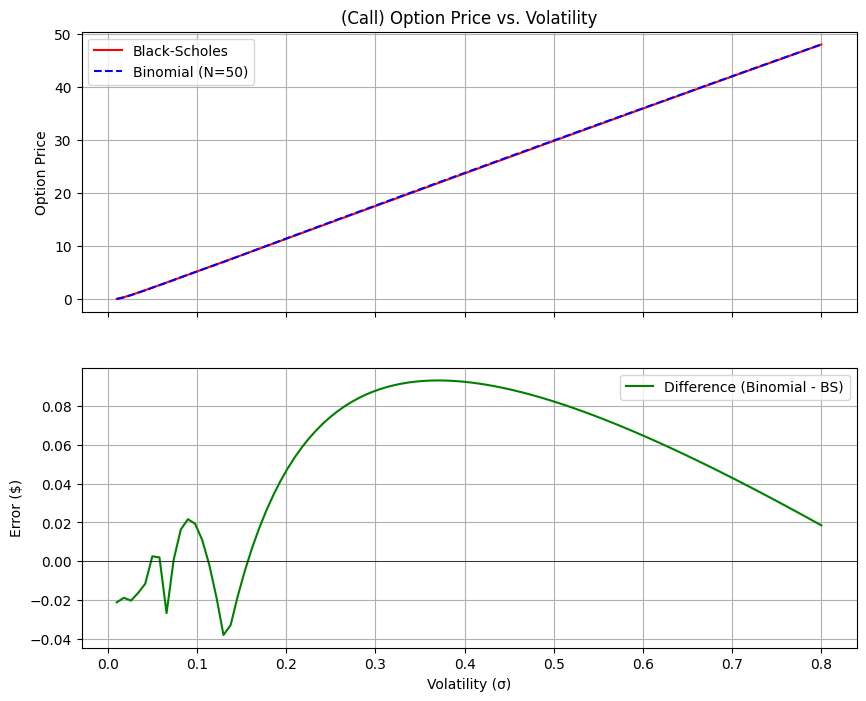

The maximum difference between binomial model and BS model is 0.52%


In [22]:
sigmas = np.linspace(0.01, 0.8, 100)
black_prices = []
bin_prices = []
df_call = CALL_DATA.copy()

for sigma in sigmas:
    df_call["sigma"] = sigma
    model = OptionPricer(**df_call)

    black_price = model.black_scholes(option_type="call")
    bin_price = model.binomial_price(option_style="european", option_type="call")

    black_prices.append(black_price)
    bin_prices.append(bin_price)

differences = np.array(bin_prices) - np.array(black_prices)
max_diff = max(differences / np.array(black_prices))


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(sigmas, black_prices, 'r-', label='Black-Scholes')
ax1.plot(sigmas, bin_prices, 'b--', label=f'Binomial (N={CALL_DATA['N']})')
ax1.set_ylabel('Option Price')
ax1.set_title('(Call) Option Price vs. Volatility')
ax1.legend()
ax1.grid(True)

ax2.plot(sigmas, differences, 'g-', label='Difference (Binomial - BS)')
ax2.set_xlabel('Volatility (σ)')
ax2.set_ylabel('Error ($)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.legend()
ax2.grid(True)

plt.show()
print(f"The maximum difference between binomial model and BS model is {max_diff:.2%}")

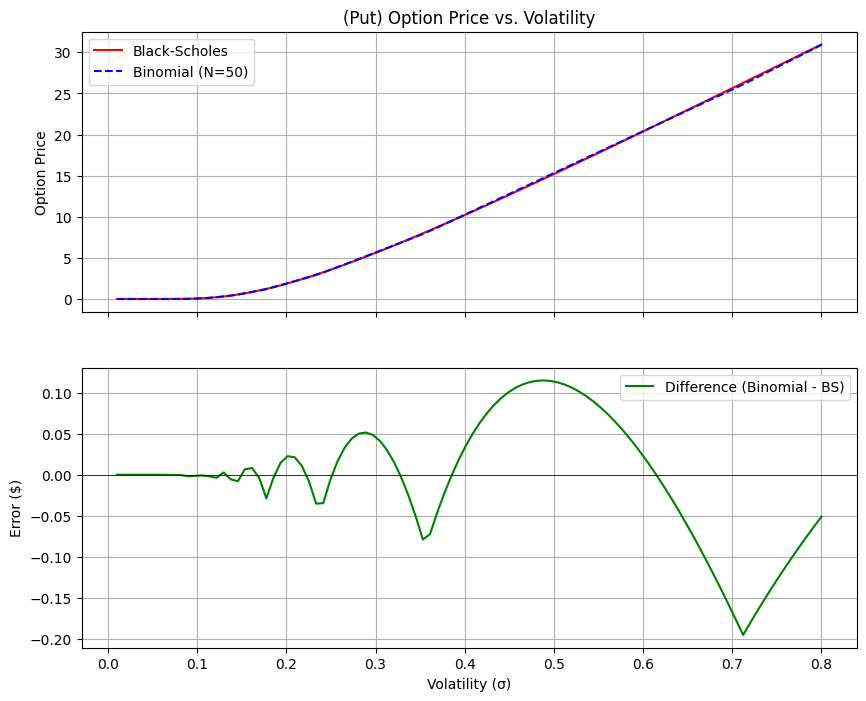

The maximum difference between binomial model and BS model is 1.19%


In [7]:
sigmas = np.linspace(0.01, 0.8, 100)
black_prices = []
bin_prices = []
df_put = PUT_DATA.copy()

for sigma in sigmas:
    df_put["sigma"] = sigma
    model = OptionPricer(**df_put)

    black_price = model.black_scholes(option_type="put")
    bin_price = model.binomial_price(option_style="european", option_type="put")

    black_prices.append(black_price)
    bin_prices.append(bin_price)

differences = np.array(bin_prices) - np.array(black_prices)
max_diff = max(differences / np.array(black_prices))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(sigmas, black_prices, 'r-', label='Black-Scholes')
ax1.plot(sigmas, bin_prices, 'b--', label=f'Binomial (N={PUT_DATA['N']})')
ax1.set_ylabel('Option Price')
ax1.set_title('(Put) Option Price vs. Volatility')
ax1.legend()
ax1.grid(True)

ax2.plot(sigmas, differences, 'g-', label='Difference (Binomial - BS)')
ax2.set_xlabel('Volatility (σ)')
ax2.set_ylabel('Error ($)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.legend()
ax2.grid(True)

plt.show()
print(f"The maximum difference between binomial model and BS model is {max_diff:.2%}")

# **4.3 Convergence Analysis**
To validate the numerical accuracy of the Binomial model, we examine the asymptotic behavior of the calculated prices as the number of time steps ($N$) increases.

Theoretical Expectation:According to the central limit theorem, as the time step $\Delta t \to 0$ (i.e., $N \to \infty$), the discrete Binomial distribution converges to the continuous Log-normal distribution used in the Black-Scholes framework.

Analysis of Discretization Error:The code below iterates $N$ from 10 to 200. We expect to see the Binomial price approach the Black-Scholes benchmark. Note that the convergence is non-monotonic; you will observe a distinct "sawtooth" oscillation pattern due to the shifting alignment of the grid nodes relative to the strike price ($K$) as $N$ changes between odd and even values.

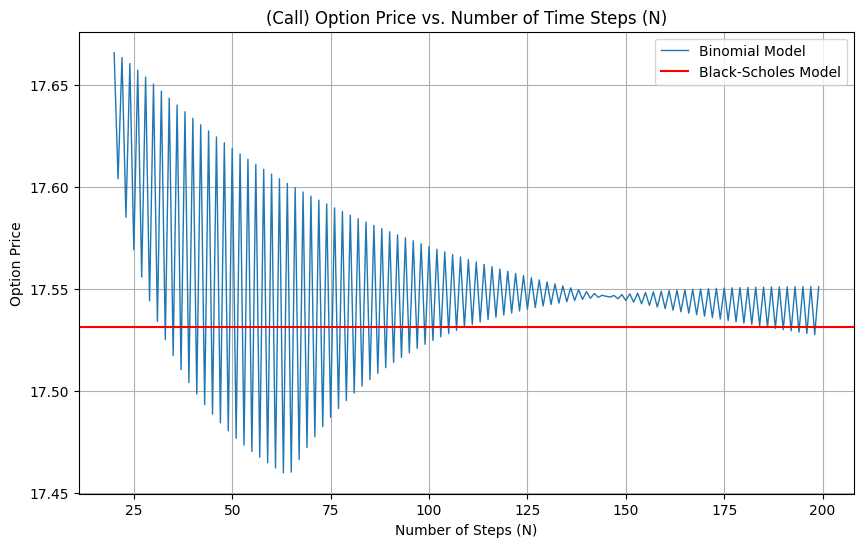

Difference between Binomial and Black-Scholes Prices: 0.11% when N = 200


In [8]:
N_range = range(20, 200)
df_call = CALL_DATA.copy()
model = OptionPricer(**df_call)

bin_prices = []
black_price = model.black_scholes(option_type = 'call')

for N in N_range:
    df_call["N"] = N
    model = OptionPricer(**df_call)
    bin_price = model.binomial_price(option_style="european", option_type="call")
    bin_prices.append(bin_price)


plt.figure(figsize=(10, 6))
plt.plot(N_range, bin_prices, label='Binomial Model', linewidth=1)
plt.axhline(black_price, color='red', label='Black-Scholes Model', linewidth=1.5)

plt.xlabel('Number of Steps (N)')
plt.ylabel('Option Price')
plt.title('(Call) Option Price vs. Number of Time Steps (N)')
plt.grid(True)
plt.legend()
plt.show()

difference = (bin_prices[-1] - black_price) / black_price
print(f"Difference between Binomial and Black-Scholes Prices: {abs(difference):.2%} when N = 200")

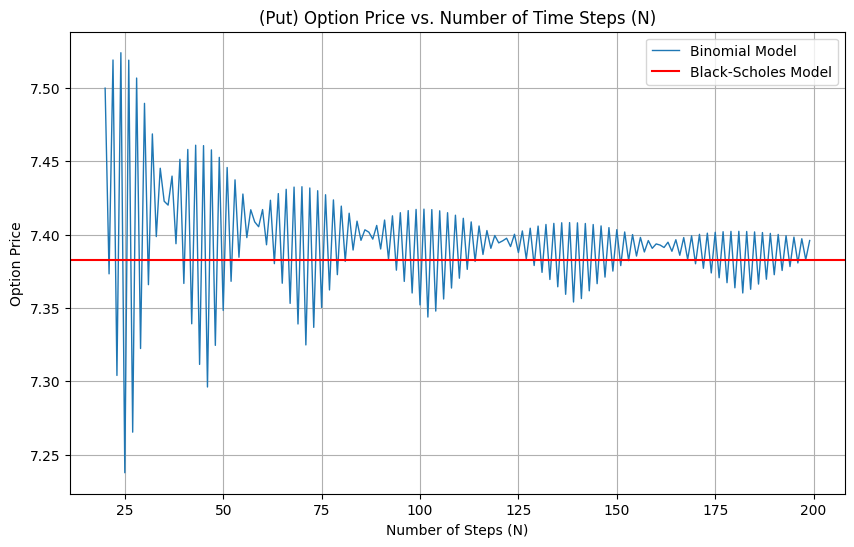

Difference between Binomial and Black-Scholes Prices: 0.18% when N = 200


In [9]:
N_range = range(20, 200)
df_put = PUT_DATA.copy()
model = OptionPricer(**df_put)

bin_prices = []
black_price = model.black_scholes(option_type = 'put')

for N in N_range:
    df_put["N"] = N
    model = OptionPricer(**df_put)
    bin_price = model.binomial_price(option_style="european", option_type="put")
    bin_prices.append(bin_price)


plt.figure(figsize=(10, 6))
plt.plot(N_range, bin_prices, label='Binomial Model', linewidth=1)
plt.axhline(black_price, color='red', label='Black-Scholes Model', linewidth=1.5)

plt.xlabel('Number of Steps (N)')
plt.ylabel('Option Price')
plt.title('(Put) Option Price vs. Number of Time Steps (N)')
plt.grid(True)
plt.legend()
plt.show()

difference = (bin_prices[-1] - black_price) / black_price
print(f"Difference between Binomial and Black-Scholes Prices: {abs(difference):.2%} when N = 200")

# **Early Exercise Boundary (American Put)**
A key feature of American options is the right to exercise before maturity. This creates an Early Exercise Boundary: a critical stock price level ($S^*$) at each point in time.
The Decision Rule:

    Below the boundary:
    The intrinsic value (profit from immediate exercise) is higher than the expected value of holding the option.
    Action: Exercise.

    Above the boundary:
    The potential for future gains outweighs the immediate profit.
    Action: Hold.

Visualization: The code below identifies the specific stock price at each time step where the decision flips from "Hold" to "Exercise" and plots this boundary curve.

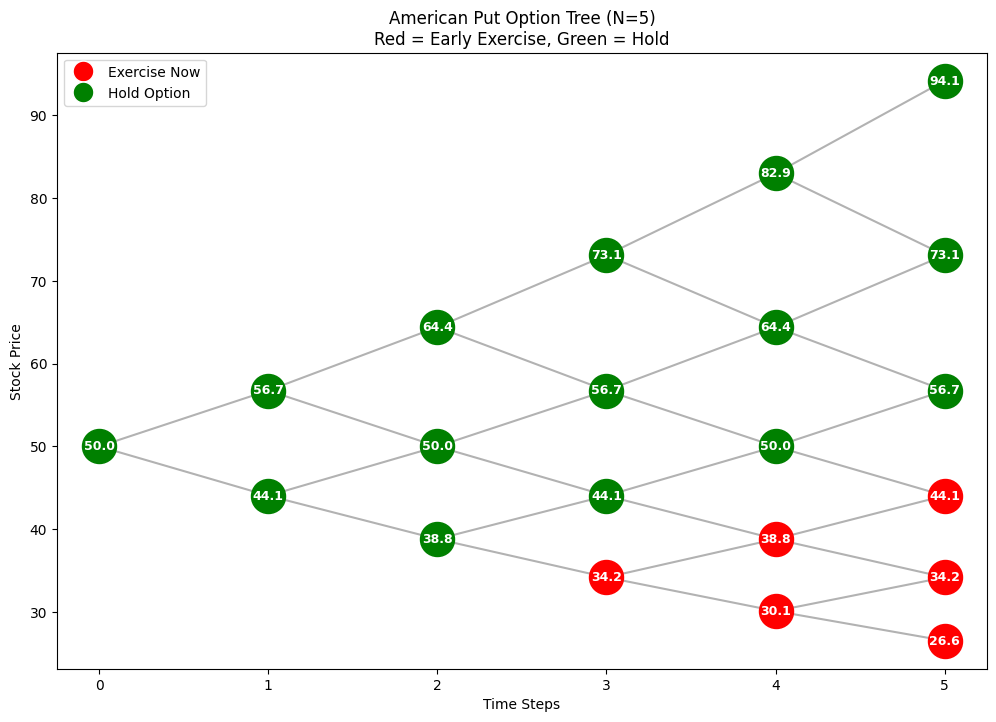

In [10]:
# --- AI GENERATION RECORD ---
# I used AI to generate the visualization code below because plotting
# trees in matplotlib is complex and purely cosmetic.
#
# PROMPT USED:
# "Write a python function using matplotlib to draw a binomial tree
# structure with nodes and connecting lines for N=3 steps."
#
# Validity:
# The algorithm has been checked and confirmed its validity.
# ---------------------------

def plot_colored_tree(s0, K, r, sigma, T, N, option_type='put'):
    model = OptionPricer(s0, K, r, sigma, T, N)
    u, d, qu, qd = model._setup_params()
    disc = model.df

    stock_tree = [np.zeros(t+1) for t in range(N+1)]
    for t in range(N+1):
        for i in range(t+1):
            stock_tree[t][i] = s0 * (u ** (t - i)) * (d ** i)

    option_tree = [np.zeros(t+1) for t in range(N+1)]
    decision_tree = [np.zeros(t+1, dtype=bool) for t in range(N+1)] # True = Exercise

    if option_type == 'put':
        option_tree[N] = np.maximum(K - stock_tree[N], 0)
    else:
        option_tree[N] = np.maximum(stock_tree[N] - K, 0)

    decision_tree[N] = option_tree[N] > 0


    for t in range(N - 1, -1, -1):
        for i in range(t + 1):
            hold_val = disc * (qu * option_tree[t+1][i] + qd * option_tree[t+1][i+1])

            price = stock_tree[t][i]
            if option_type == 'put':
                intrinsic = max(K - price, 0)
            else:
                intrinsic = max(price - K, 0)

            if intrinsic > hold_val + 1e-9:
                decision_tree[t][i] = True
                option_tree[t][i] = intrinsic
            else:
                decision_tree[t][i] = False
                option_tree[t][i] = hold_val


    plt.figure(figsize=(12, 8))

    for t in range(N):
        for i in range(t+1):
            plt.plot([t, t+1], [stock_tree[t][i], stock_tree[t+1][i]], 'k-', alpha=0.3)
            plt.plot([t, t+1], [stock_tree[t][i], stock_tree[t+1][i+1]], 'k-', alpha=0.3)


    for t in range(N+1):
        for i in range(t+1):
            price = stock_tree[t][i]
            is_exercise = decision_tree[t][i]

            color = 'red' if is_exercise else 'green'
            label = 'Exercise' if is_exercise and t==0 else None # Label only once to keep clean

            plt.scatter(t, price, color=color, s=600, zorder=3)

            plt.text(t, price, f"{price:.1f}", ha='center', va='center',
                     color='white', fontsize=9, fontweight='bold')


    plt.title(f"American {option_type.title()} Option Tree (N={N})\nRed = Early Exercise, Green = Hold")
    plt.xlabel("Time Steps")
    plt.ylabel("Stock Price")
    plt.grid(False)



    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=15, label='Exercise Now'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=15, label='Hold Option')]
    plt.legend(handles=legend_elements)

    plt.show()

# --- RUN IT ---
# Use N=5 for a clean tree
# Use a Put option to see the Red Nodes clearly
plot_colored_tree(s0=50, K=52, r=0.05, sigma=0.4, T=0.5, N=5, option_type='put')